In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../dataset/clean/stats_by_player.csv')
df.columns

Index(['personName', 'teamName', 'season_year', 'position', 'minutes',
       'fieldGoalsMade', 'fieldGoalsAttempted', 'fieldGoalsPercentage',
       'threePointersMade', 'threePointersAttempted',
       'threePointersPercentage', 'freeThrowsMade', 'freeThrowsAttempted',
       'freeThrowsPercentage', 'reboundsOffensive', 'reboundsDefensive',
       'reboundsTotal', 'assists', 'steals', 'blocks', 'turnovers',
       'foulsPersonal', 'points', 'plusMinusPoints'],
      dtype='object')

In [81]:
features = ['fieldGoalsMade', 'fieldGoalsAttempted',
       'threePointersMade', 'threePointersAttempted',
        'freeThrowsMade', 'freeThrowsAttempted', 'reboundsOffensive', 'reboundsDefensive',
        'assists', 'steals', 'blocks', 'turnovers', 'foulsPersonal']

df = df[(
    ['personName', 'teamName', 'season_year', 'position', 'points', 'minutes'] +
    features
)]

In [82]:
# Normalizando dados
from sklearn import preprocessing

min_max_scaler = preprocessing.MinMaxScaler()
scaled = min_max_scaler.fit_transform(
    df[features].values
)

df[features] = scaled

df

,personName,teamName,season_year,position,points,minutes,fieldGoalsMade,fieldGoalsAttempted,threePointersMade,threePointersAttempted,freeThrowsMade,freeThrowsAttempted,reboundsOffensive,reboundsDefensive,assists,steals,blocks,turnovers,foulsPersonal
0,AJ Green,Bucks,2022-23,G,4.400000,9.855714,0.100952,0.132275,0.157143,0.227626,0.009143,0.006015,0.013187,0.069643,0.036975,0.034286,0.000000,0.036735,0.147619
1,AJ Green,Bucks,2023-24,G,4.500000,10.969345,0.098810,0.129630,0.154018,0.228981,0.024286,0.017857,0.012363,0.061384,0.031513,0.032143,0.017857,0.030612,0.145833
2,AJ Griffin,Hawks,2022-23,F,8.666667,19.083660,0.226144,0.270879,0.183824,0.284161,0.032941,0.024768,0.036199,0.100490,0.057670,0.117647,0.044118,0.072829,0.196078
3,AJ Griffin,Hawks,2022-23,G,9.380952,20.389683,0.238095,0.282187,0.154762,0.245692,0.080000,0.057644,0.047619,0.101190,0.064426,0.114286,0.035714,0.108844,0.214286
4,AJ Griffin,Hawks,2023-24,F,2.466667,8.998889,0.062222,0.106173,0.058333,0.126459,0.010667,0.007018,0.005128,0.058333,0.019608,0.013333,0.033333,0.057143,0.055556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9922,Zion Williamson,Pelicans,2022-23,F,26.000000,32.968966,0.655172,0.598978,0.030172,0.049712,0.488276,0.450091,0.153846,0.310345,0.269777,0.220690,0.137931,0.487685,0.373563
9923,Zion Williamson,Pelicans,2023-24,F,22.871429,31.527619,0.594286,0.578836,0.010714,0.019511,0.396571,0.371429,0.134066,0.253571,0.295798,0.217143,0.167857,0.393878,0.378571
9924,Zoran Dragic,Heat,2014-15,G,2.200000,6.178333,0.060000,0.081481,0.037500,0.068288,0.008000,0.010526,0.023077,0.012500,0.023529,0.040000,0.000000,0.071429,0.083333
9925,Zoran Dragic,Suns,2014-15,G,1.000000,2.238889,0.022222,0.049383,0.000000,0.063230,0.026667,0.026316,0.025641,0.010417,0.009804,0.000000,0.000000,0.000000,0.027778


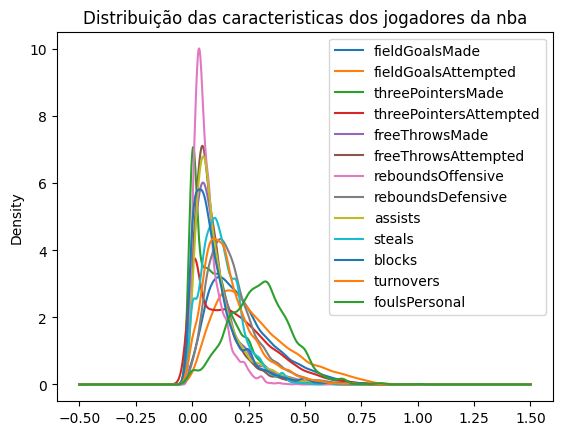

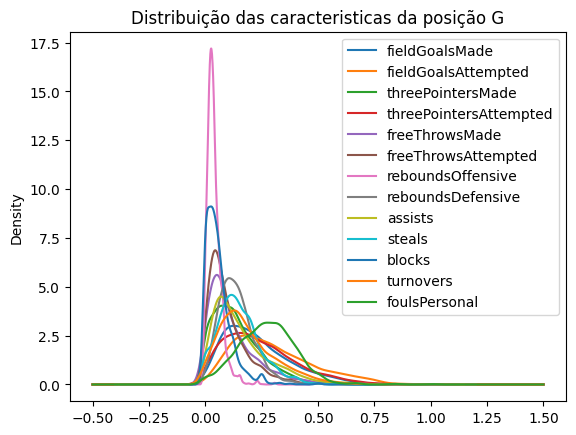

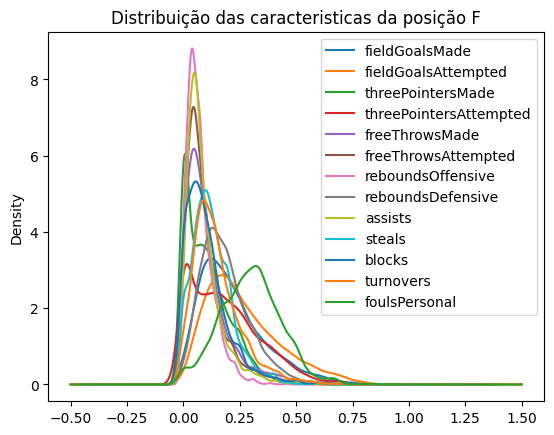

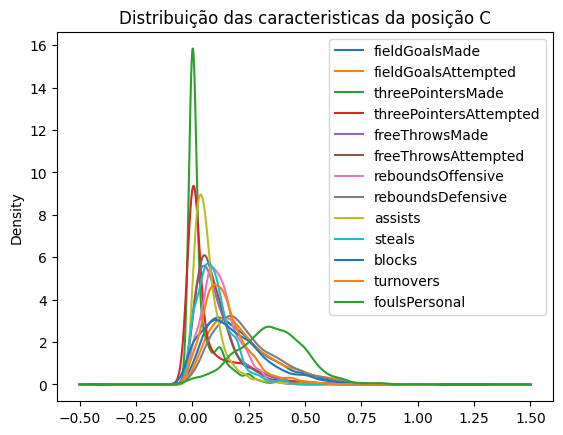

In [25]:

def mostra_distribuica_features(df):
    plt.figure()
    plt.title(f'Distribuição das caracteristicas dos jogadores da nba')
    for col in features:
        df[col].plot.kde(label=col)
        plt.legend()
    
    plt.figure()
    plt.title(f'Distribuição das caracteristicas da posição G')
    for col in features:
        
        df[df['position'].str.count('G') > 0][col].plot.kde(label=col)
        plt.legend()
    
    plt.figure()
    plt.title(f'Distribuição das caracteristicas da posição F')
    for col in features:
    
        df[df['position'].str.count('F') > 0][col].plot.kde(label=col)
        plt.legend()
    
    plt.figure()
    plt.title(f'Distribuição das caracteristicas da posição C')
    for col in features:
    
        df[df['position'].str.count('C') > 0][col].plot.kde(label=col)
        plt.legend()

mostra_distribuica_features(df)

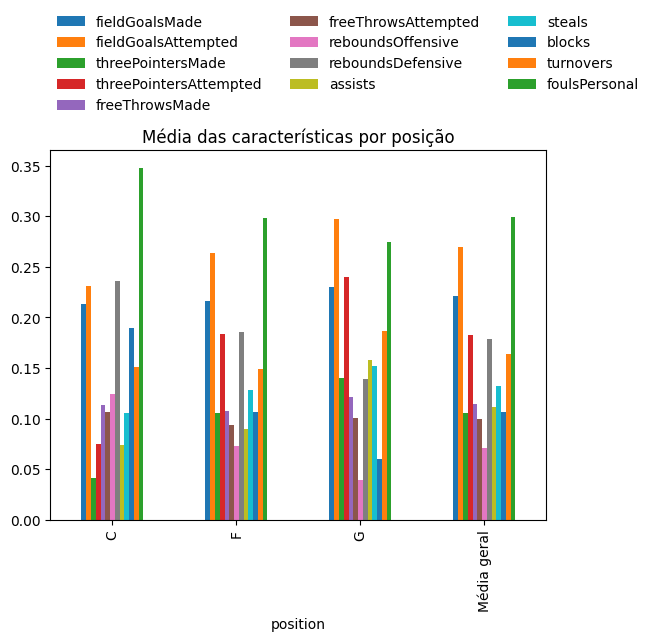

In [26]:
def mostra_media_features_em_barra(df):
    df_media_features= df.groupby(by = ['position']).mean(numeric_only=True).reset_index()

    df_media_geral = df.mean(numeric_only=True)
    df_media_geral['position'] = 'Média geral'
    df_media_features = pd.concat([df_media_features, df_media_geral.to_frame().T])
    
    df_media_features.set_index("position")[features].plot.bar()
    plt.title('Média das características por posição')
    plt.legend(loc='upper center', bbox_to_anchor=(0.6, 1.4), ncol=3, frameon=False)
    

mostra_media_features_em_barra(df)

In [27]:
# Vendo matriz de correção entre posição e caracteristica
import seaborn as sns

def plot_heatmap(df, tittle):
    features_corr = features + ['minutes']
    df_corr = df[features_corr].copy()

    plt.figure
    sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", annot_kws={"size": 6})
    plt.title(tittle)
    plt.show

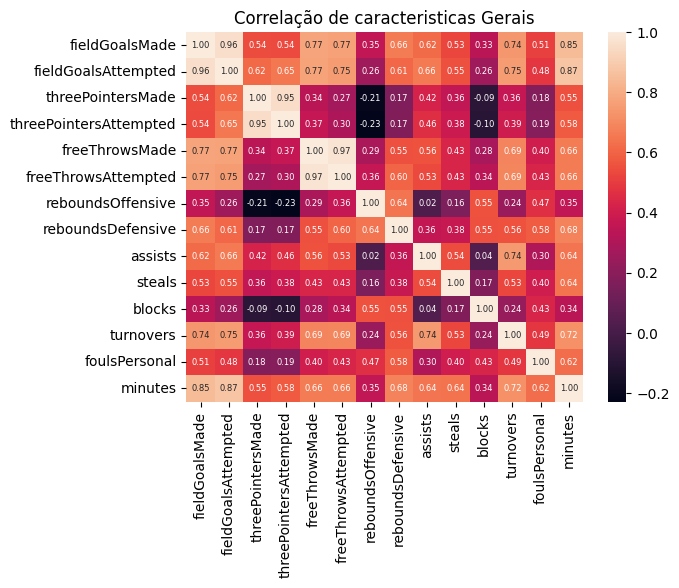

In [28]:
plot_heatmap(df, "Correlação de caracteristicas Gerais")

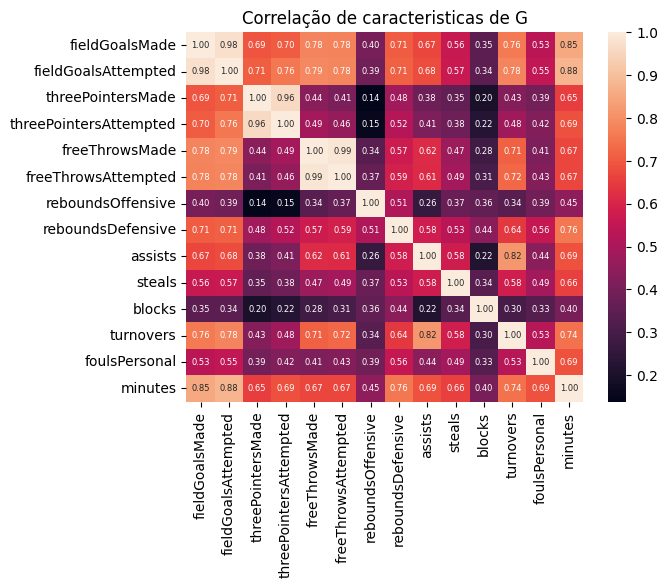

In [29]:
plot_heatmap(df[df['position'].str.count('G') > 0], "Correlação de caracteristicas de G")

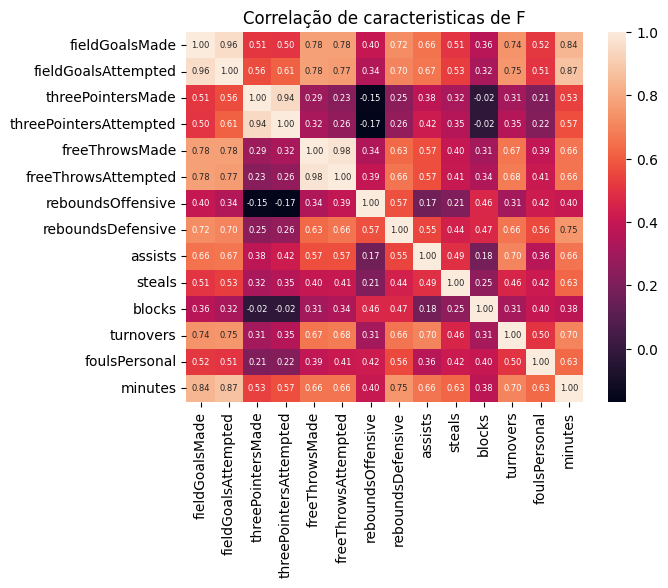

In [30]:
plot_heatmap(df[df['position'].str.count('F') > 0], "Correlação de caracteristicas de F")

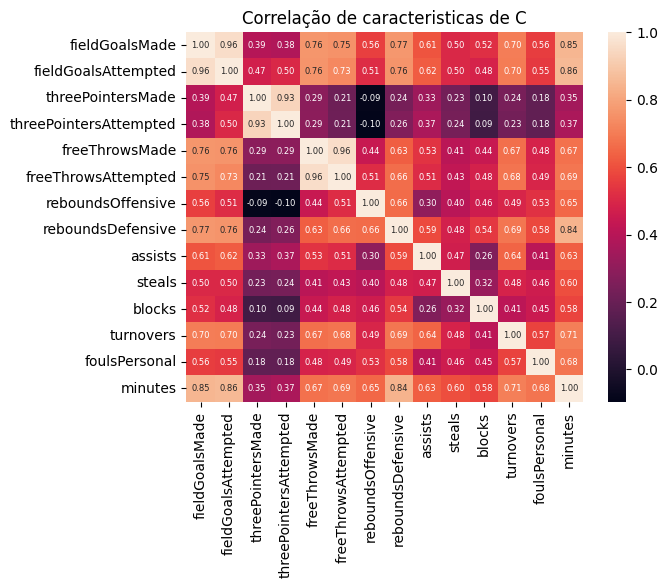

In [31]:
plot_heatmap(df[df['position'].str.count('C') > 0], "Correlação de caracteristicas de C")

In [85]:
df_media_features = df.groupby(by='position').mean(numeric_only=True).reset_index()
featuresMedia = ['fieldGoalsMade', 'fieldGoalsAttempted',
       'threePointersMade', 'threePointersAttempted',
        'freeThrowsMade', 'freeThrowsAttempted', 'reboundsOffensive', 'reboundsDefensive',
        'assists', 'steals', 'blocks', 'turnovers', 'foulsPersonal', 'points', 'minutes']
media_geral_dict = df[featuresMedia].mean().to_dict()
media_geral_dict['position'] = 'Média geral'
df_media_geral = pd.DataFrame([media_geral_dict])
df_media_features = pd.concat([df_media_features, df_media_geral], ignore_index=True)
df_media_features

,position,points,minutes,fieldGoalsMade,fieldGoalsAttempted,threePointersMade,threePointersAttempted,freeThrowsMade,freeThrowsAttempted,reboundsOffensive,reboundsDefensive,assists,steals,blocks,turnovers,foulsPersonal
0,C,8.147050,19.299429,0.213364,0.230788,0.041499,0.075086,0.113130,0.106772,0.124731,0.235916,0.073821,0.105392,0.189309,0.151466,0.347811
1,F,8.669490,20.860981,0.215831,0.264134,0.105860,0.183862,0.107815,0.094184,0.073018,0.185843,0.089779,0.128053,0.106962,0.148873,0.298108
2,G,9.558830,21.934385,0.230425,0.297409,0.140538,0.240203,0.121741,0.100753,0.039716,0.139119,0.158282,0.151588,0.059645,0.186560,0.274355
3,Média geral,8.891755,20.936711,0.220741,0.269596,0.105429,0.182292,0.114087,0.099227,0.071344,0.178844,0.111921,0.132108,0.106418,0.163407,0.299565


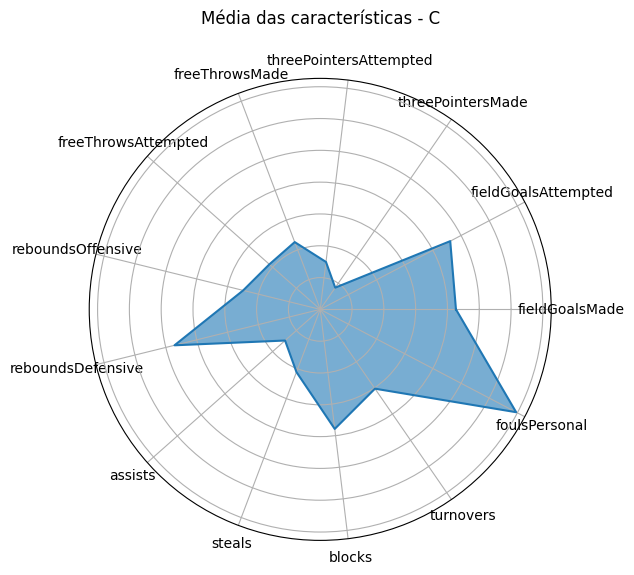

In [116]:
linha = df_media_features.iloc[0]
values = linha[features].tolist()
values += values[:1]
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, label=linha['position'])
ax.fill(angles, values, alpha=0.6)
ax.set_title(f"Média das características - {linha['position']}", y=1.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticklabels([])
plt.show()

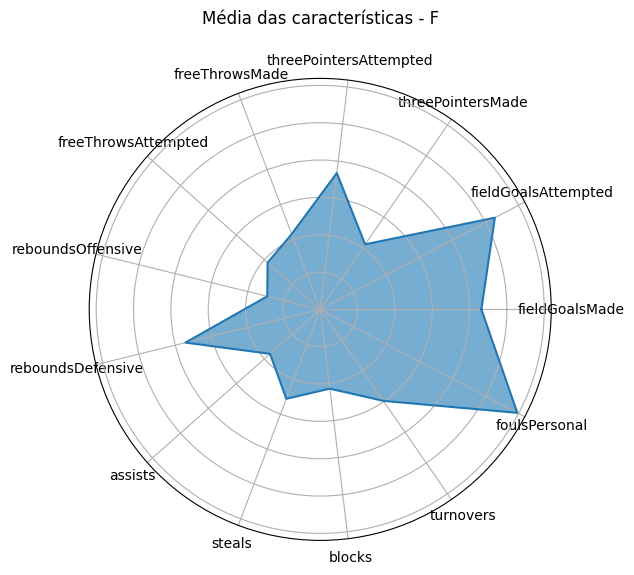

In [110]:
linha = df_media_features.iloc[1]
values = linha[features].tolist()
values += values[:1]
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, label=linha['position'])
ax.fill(angles, values, alpha=0.6)
ax.set_title(f"Média das características - {linha['position']}", y=1.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticklabels([])

plt.show()

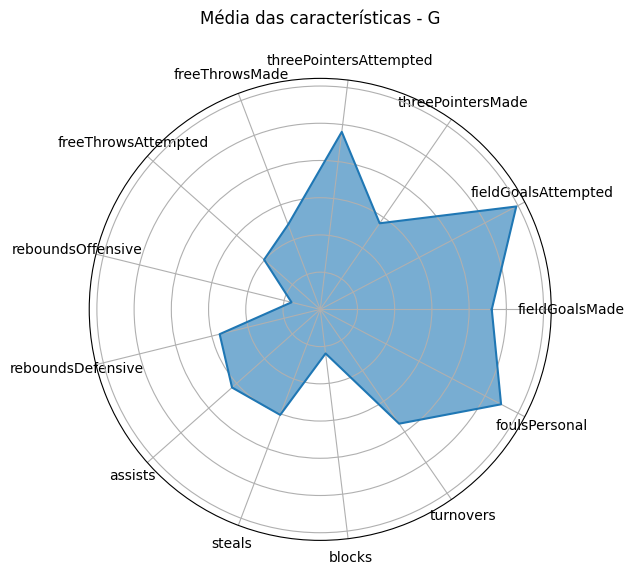

In [111]:
linha = df_media_features.iloc[2]
values = linha[features].tolist()
values += values[:1]
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, label=linha['position'])
ax.fill(angles, values, alpha=0.6)
ax.set_title(f"Média das características - {linha['position']}", y=1.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticklabels([])

plt.show()

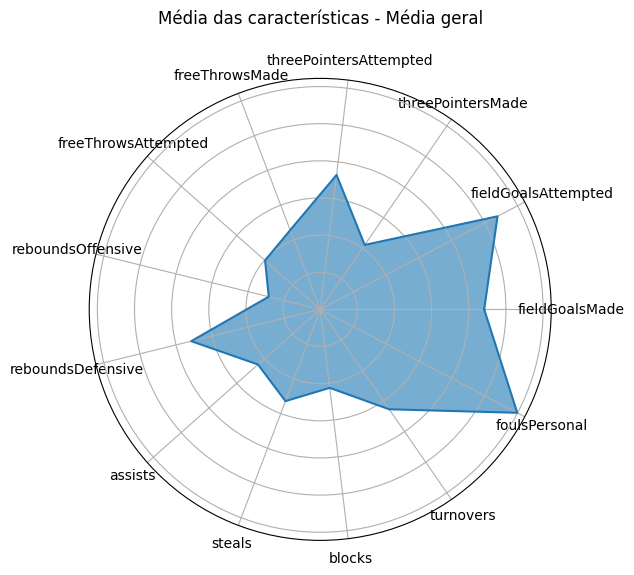

In [112]:
linha = df_media_features.iloc[3]
values = linha[features].tolist()
values += values[:1]
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, label=linha['position'])
ax.fill(angles, values, alpha=0.6)
ax.set_title(f"Média das características - {linha['position']}", y=1.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticklabels([])

plt.show()